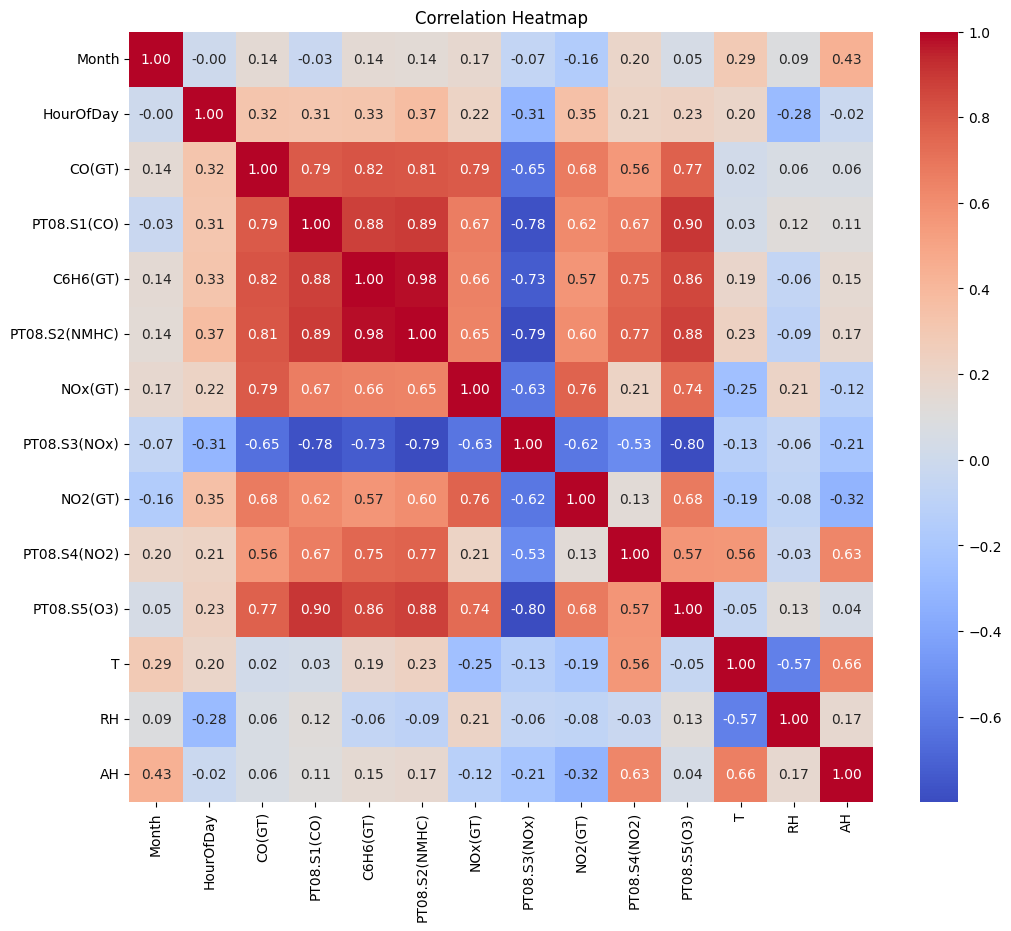

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import sys
import os

# Add project root to path to use methods from src.utils
sys.path.append(os.path.abspath(".."))
from src.data_preprocessing import *

# Load your dataset
df: pd.DataFrame = pd.read_csv('../data/AirQualityUCIProcessed.csv')
df_numeric = df.select_dtypes(include='number')

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### Heatmap interpretation
* Strong positive correlations (≥ 0.8) among key pollution sensors:
CO(GT), C6H6(GT), PT08.S1(CO), PT08.S2(NMHC), PT08.S5(O3) form a highly redundant cluster.
Indicates these sensors largely measure the same pollution sources.
* PT08.S3(NOx) sensor behaves differently:
Strongly negatively correlated (around -0.7 to -0.8) with other pollution sensors.
Reflects different chemical or atmospheric reactions, possibly ozone-NOx interaction.
* NOx(GT) and NO2(GT) show moderate positive correlation (~0.76):
Logical because NO2 is part of NOx compounds.
* Weather variables show expected physical patterns:
Temperature (T) positively correlated with absolute humidity (AH) (~0.66).
Temperature negatively correlated with relative humidity (RH) (~-0.57).
* Weather variables have weak correlations with pollution sensors:
Suggesting pollution levels are mainly driven by emissions rather than weather.
* Month shows weak correlations with pollutants and weather (~0.1–0.4):
Implies limited seasonality in pollution levels.
* Multicollinearity is present among pollution sensors:
Important for modeling—consider dimensionality reduction or feature selection.
* Sensor drift (not visible in heatmap) is a known challenge in this dataset:
Sensor responses change over time due to aging and environmental factors.
* Practical implications:
Reduce redundant features before modeling.
Consider the special role of PT08.S3(NOx) sensor.
Use weather variables carefully, as their impact is limited but physically consistent.

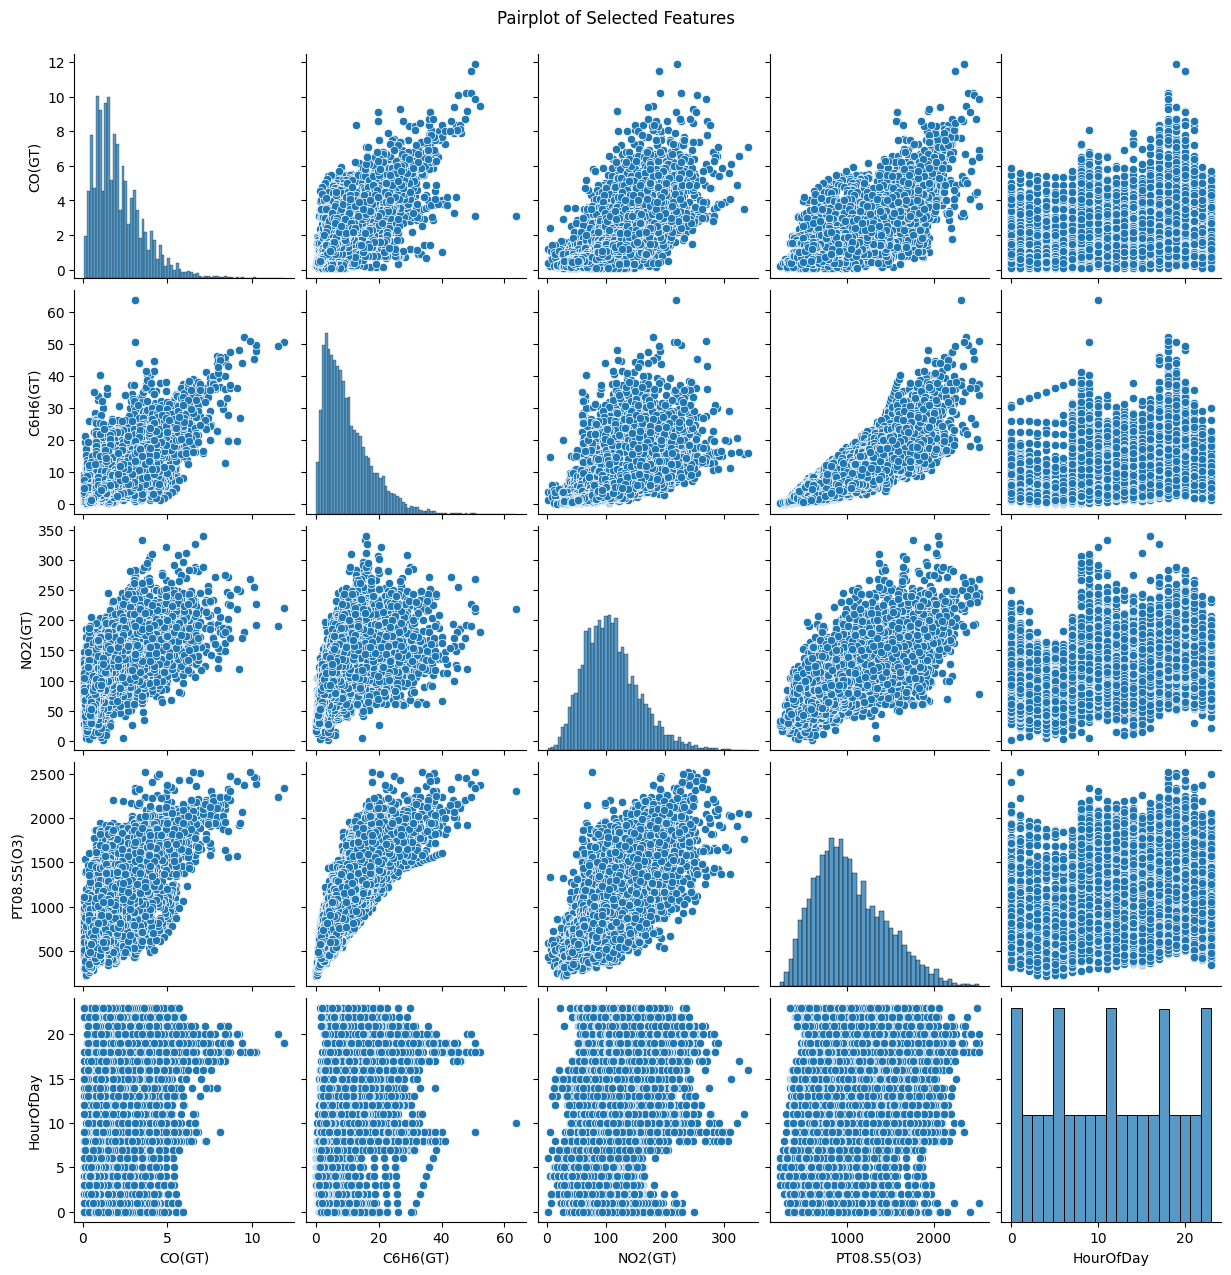

In [27]:
from sklearn.preprocessing import StandardScaler
import pickle

# Select relevant features
features_to_plot = ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S5(O3)', 'HourOfDay']
features = ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S5(O3)', 'HourOfDay', 'T', 'RH', 'CO(GT)ToHigh', 'C6H6(GT)ToHigh', 'NO2(GT)ToHigh', 'PT08.S5(O3)ToHigh']
# Save variable 'features' for next notebook
with open('../data/features.pkl', 'wb') as file:
    pickle.dump(features, file)
X = df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X))

# Pairplot of selected features
# Assigning a hue variable adds a semantic mapping and changes the default marginal plot to a layered kernel density estimate (KDE)
sns.pairplot(df[features_to_plot]) # takes 2 seconds
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

# Interpretation:
* Strong positive correlations (scatterplots off diagonal)
* CO(GT) vs C6H6(GT): clear positive trend, moderately strong correlation (many points rising diagonally).
* CO(GT) vs PT08.S5(O3): strong positive trend with some spread.
* C6H6(GT) vs PT08.S5(O3): very clear, strong positive correlation, almost linear pattern.
* NO2(GT) positively correlates with all others but with more scatter, showing weaker but consistent relationships.
* These relationships confirm that these pollutants often increase and decrease together, likely due to common sources such as traffic emissions or industrial activity.

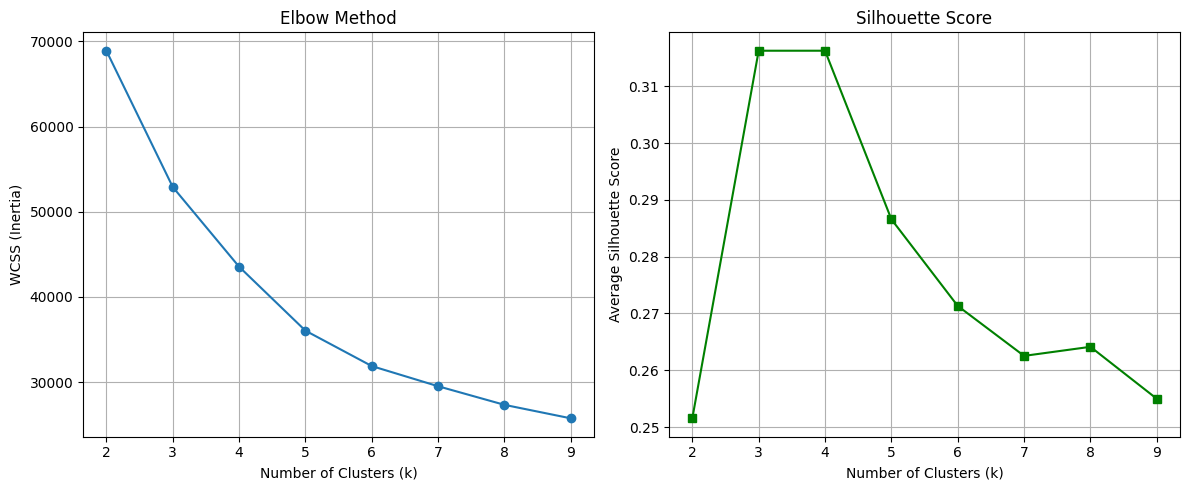

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# K-Means Clustering

# Evaluate range of K values
k_range = range(2, 10)  # NOTE: range from 2 to 10 normally a good starting point
wcss = []               # For Elbow Method
silhouette_scores = []  # For Silhouette Score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)          # NOTE: X or X_scaled depending on what you want to process
    wcss.append(kmeans.inertia_)  # Inertia = WCSS
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Method (from prof. Carmen)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='green')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

#### Interpretation:
Both techniques suggest k = 3–4 as optimal. I will try '3' first, because I want to get three categories at the end:      
1) Green: low pollution
2) Yellow: moderate pollution
3) Red: high pollution conditions

Silhouette Score for k=3: 0.31


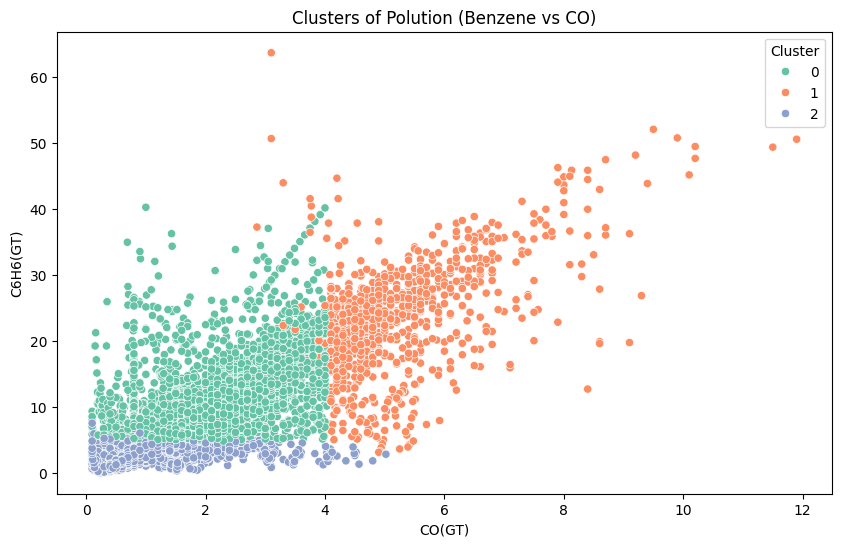

In [29]:
# Based on elbow plot, let's assume optimal k=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = kmeans.labels_

# Silhouette Score
score = silhouette_score(X_scaled, kmeans.labels_)
print(f'Silhouette Score for k={k_optimal}: {score:.2f}')

# Visualize clusters
plt.figure(figsize=(10, 6))
col_x = 'CO(GT)'
col_y = 'C6H6(GT)'
sns.scatterplot(x=df[col_x], y=df[col_y], hue=df['Cluster'], palette='Set2')
plt.title(f'Clusters of Polution ({get_label_short(col_y)} vs {get_label_short(col_x)})')
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.legend(title='Cluster')
plt.show()

# Save datset with clusters
df.to_csv('../data/AirQualityUCIClustered.csv', index=False)

In [30]:
# Save kmeans-model
with open("../models/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# TODO: loading (check for model before running)
# with open("kmeans_model.pkl", "rb") as f:
#    model = pickle.load(f)